In [14]:
import numpy as np
import mplfinance as mpf
import yfinance as yf
import matplotlib as mpl
import matplotlib.pyplot as plt

In [10]:
stock=yf.download("RELIANCE.NS",start='2019-01-01',end='2024-12-31')

[*********************100%***********************]  1 of 1 completed


In [11]:
stock.tail()

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2024-12-23,1217.437744,1222.318155,1208.373847,1210.166735,10052824
2024-12-24,1217.885864,1228.642950,1216.142826,1217.437703,6734917
2024-12-26,1211.710571,1222.816119,1209.419672,1219.379892,10016178
2024-12-27,1216.192749,1223.015476,1212.158811,1213.453688,7000397
2024-12-30,1205.883789,1218.334064,1203.294156,1211.561187,8818766


In [12]:
stock=stock[['Open','High','Low','Close','Volume']]

In [13]:
stock

Price,Open,High,Low,Close,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2019-01-01,500.380481,501.292086,493.643505,498.490540,9746670
2019-01-02,495.600125,501.158692,489.596886,491.998199,15628818
2019-01-03,492.487392,495.644647,484.749906,485.928314,16288287
2019-01-04,487.996041,491.131062,480.747693,488.551880,18516544
2019-01-07,492.265036,497.356669,489.596920,491.264496,12060290
...,...,...,...,...,...
2024-12-23,1210.166735,1222.318155,1208.373847,1217.437744,10052824
2024-12-24,1217.437703,1228.642950,1216.142826,1217.885864,6734917


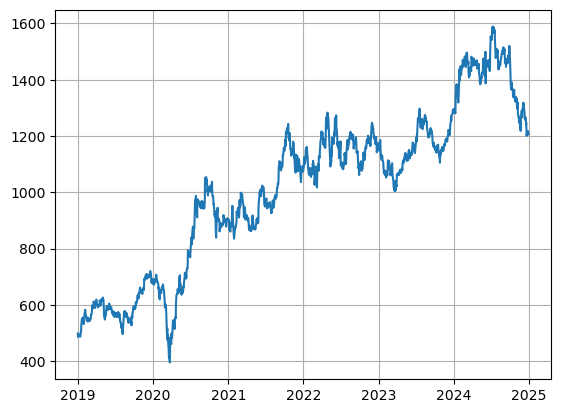

In [15]:
plt.plot(stock['Close'])
plt.grid(True)

In [16]:
stock.columns=['Open','High','Low','Close','Volume']#renaming the sequence
stock

,Open,High,Low,Close,Volume
Date,,,,,
2019-01-01,500.380481,501.292086,493.643505,498.490540,9746670
2019-01-02,495.600125,501.158692,489.596886,491.998199,15628818
2019-01-03,492.487392,495.644647,484.749906,485.928314,16288287
2019-01-04,487.996041,491.131062,480.747693,488.551880,18516544
2019-01-07,492.265036,497.356669,489.596920,491.264496,12060290
...,...,...,...,...,...
2024-12-23,1210.166735,1222.318155,1208.373847,1217.437744,10052824
2024-12-24,1217.437703,1228.642950,1216.142826,1217.885864,6734917
2024-12-26,1219.379892,1222.816119,1209.419672,1211.710571,10016178


C:\Users\HP\anaconda3\Lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


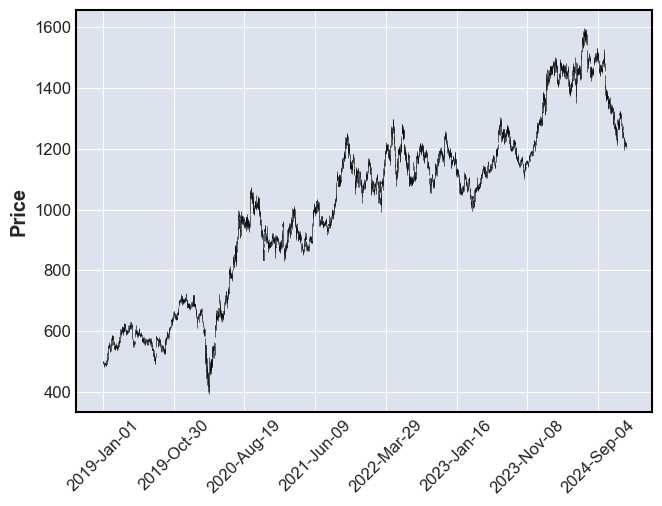

In [17]:
mpf.plot(stock,type='candle',volume=False)

In [18]:
stock_last3m=stock.tail(63)
stock_last6m=stock.tail(126)
stock_last1y=stock.tail(252)

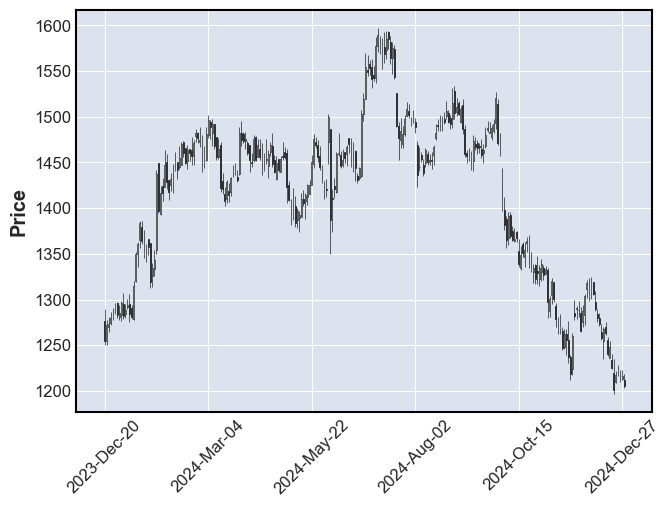

In [19]:
mpf.plot(stock_last1y,type='candle',volume=False)

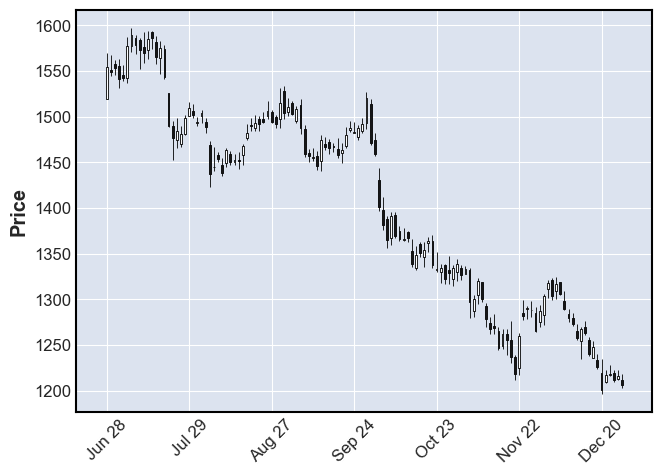

In [20]:
mpf.plot(stock_last6m,type='candle',volume=False)

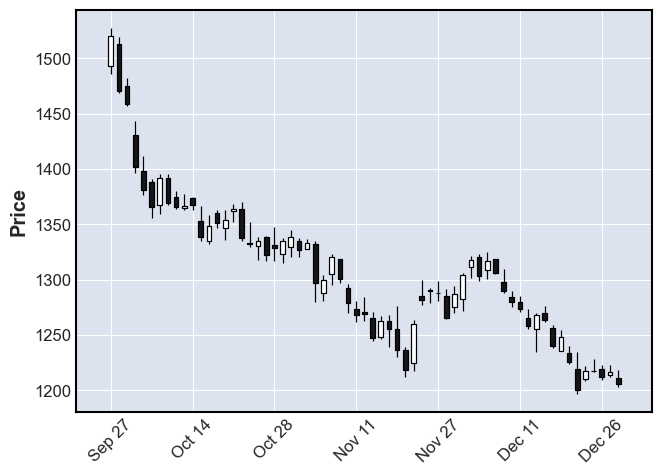

In [21]:
mpf.plot(stock_last3m,type='candle',volume=False)

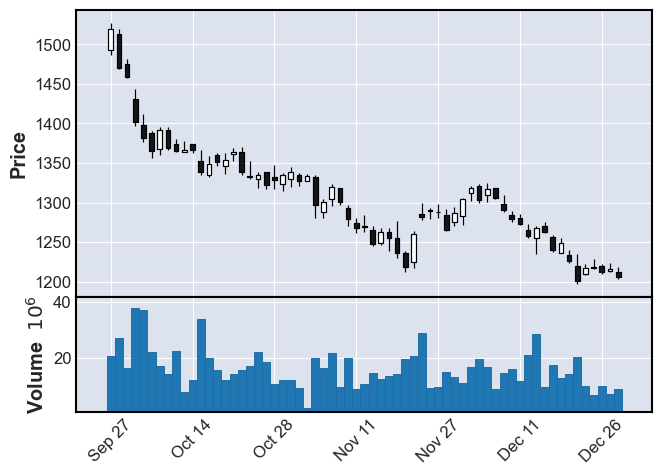

In [22]:
mpf.plot(stock_last3m,type='candle',volume=True)

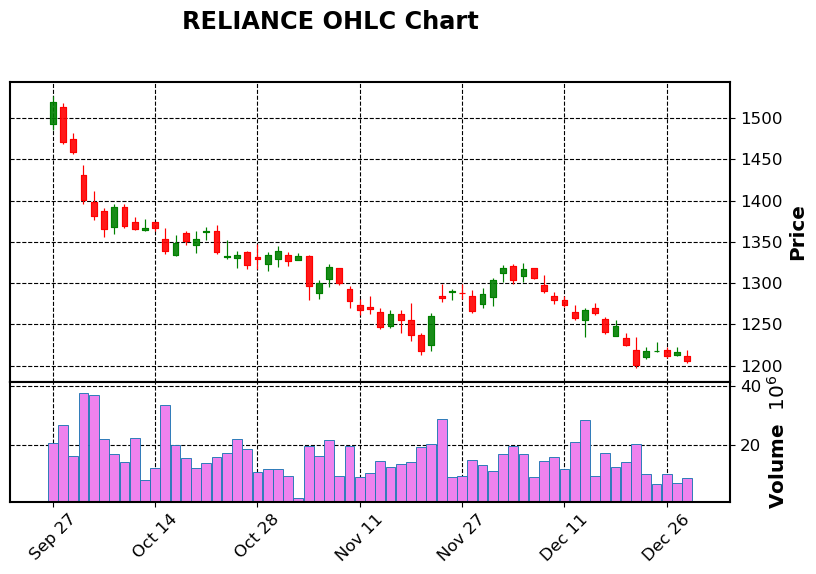

In [23]:
mc=mpf.make_marketcolors(
    up='Green',
    down='red',
    edge='inherit',#black
    wick='inherit',
    volume='violet'
)

style=mpf.make_mpf_style(
    base_mpf_style='classic',
    marketcolors=mc,
    facecolor='white',
    gridcolor='black'
)
mpf.plot(stock_last3m,
         type='candle',
         style=style,
         title="RELIANCE OHLC Chart",
         figsize=(10,6),
         volume=True
)


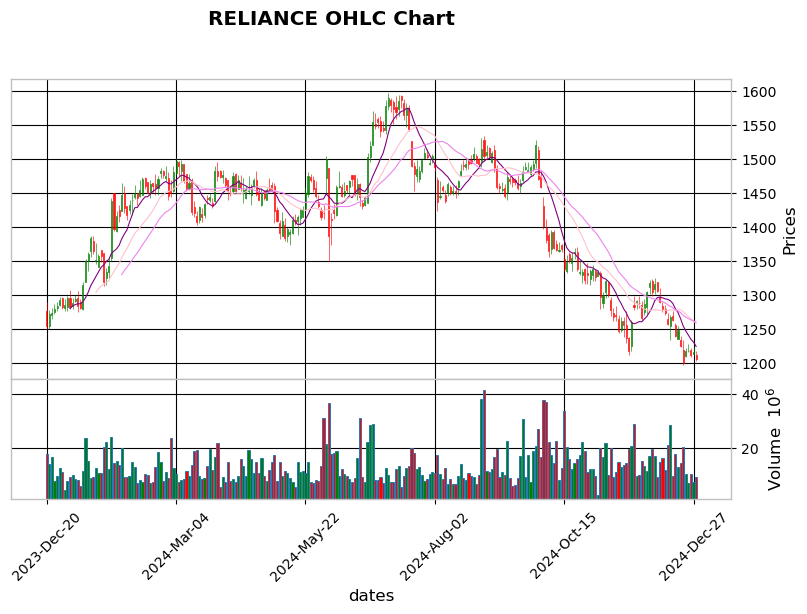

In [24]:
mc=mpf.make_marketcolors(
    up='Green',
    down='red',
    edge='inherit',#black
    wick='inherit',
    volume='inherit'
)

style=mpf.make_mpf_style(
    base_mpf_style='checkers',#yahoo
    marketcolors=mc,
    facecolor='white',
    gridcolor='black'
)
mpf.plot(stock_last1y,
         xlabel='dates',
         ylabel='Prices',
         type='candle',
         style=style,
         title="RELIANCE OHLC Chart",
         figratio=(12,6),
         figscale=1.2,
         figsize=(10,6),
         volume=True,
         mav=[10,20,30],
         mavcolors=['purple','pink','violet'],
)


In [25]:
weekly_stock=stock.resample('W').agg({
    'Open':'first',
    'High':'max',
    'Low':'min',
    'Close':'last',
    'Volume':'sum'
})
weekly_stock

,Open,High,Low,Close,Volume
Date,,,,,
2019-01-06,500.380481,501.292086,480.747693,488.551880,60180319
2019-01-13,492.265036,497.356669,484.082864,488.285126,60043136
2019-01-20,486.928841,529.129330,483.104550,526.661316,117527322
2019-01-27,530.952469,562.391700,528.573390,554.076111,151207265
2019-02-03,556.077176,558.500723,529.662949,555.832581,98781070
...,...,...,...,...,...
2024-12-08,1282.876371,1324.659370,1271.969978,1306.332642,73398411
2024-12-15,1297.816673,1309.768937,1234.668888,1267.786621,91955139
2024-12-22,1269.928060,1275.904192,1196.720439,1200.505371,74177300


In [26]:
delta_last1y=stock_last1y['Close'].diff()

#gains and losses
gain=delta_last1y.clip(lower=0)
loss=-delta_last1y.clip(upper=0)

#Average gain and loss
avg_gain=gain.rolling(14).mean()
avg_loss=loss.rolling(14).mean()

#RSI calculation
rs=avg_gain/avg_loss
stock_last1y['RSI']=100-(100/(1+rs))

C:\Users\HP\AppData\Local\Temp\ipykernel_17092\592560438.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stock_last1y['RSI']=100-(100/(1+rs))


In [27]:
stock_last1y

,Open,High,Low,Close,Volume,RSI
Date,,,,,,
2023-12-20,1276.080186,1289.878086,1250.742696,1254.291382,17736722,NaN
2023-12-21,1254.217020,1277.296201,1249.874163,1271.861450,13765454,NaN
2023-12-22,1270.397340,1280.968997,1264.466141,1273.102295,16541784,NaN
2023-12-26,1274.566338,1286.453333,1271.935784,1279.554443,7465664,NaN
2023-12-27,1281.515009,1290.399205,1277.097752,1283.922241,9204156,NaN
...,...,...,...,...,...,...
2024-12-23,1210.166735,1222.318155,1208.373847,1217.437744,10052824,24.365499
2024-12-24,1217.437703,1228.642950,1216.142826,1217.885864,6734917,26.460940
2024-12-26,1219.379892,1222.816119,1209.419672,1211.710571,10016178,20.062378


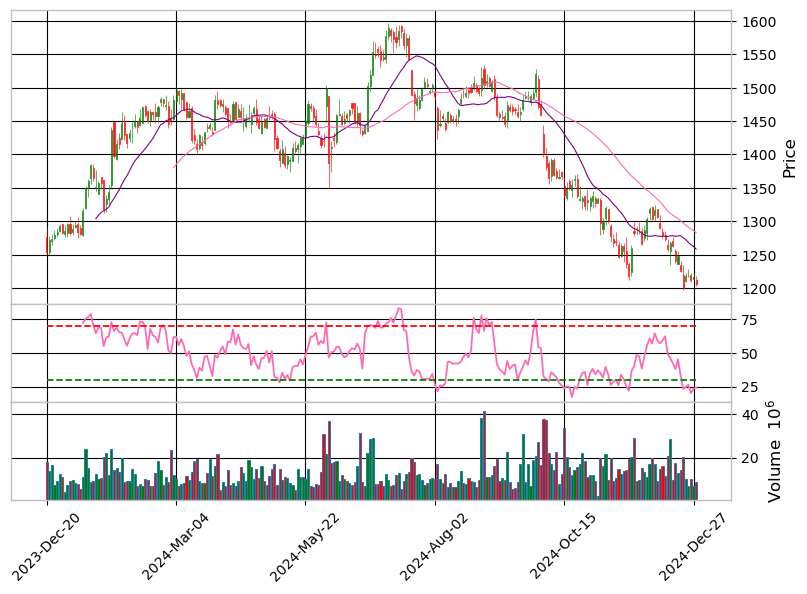

In [28]:
apds=[
    mpf.make_addplot(stock_last1y['RSI'],panel=1,color='hotpink'),
    mpf.make_addplot([70]*len(stock_last1y),panel=1,color='red',linestyle='--'),
    mpf.make_addplot([30]*len(stock_last1y),panel=1,color='green',linestyle='--')
]

mpf.plot(
    stock_last1y,
    type='candle',
    style=style,
    addplot=apds,
    panel_ratios=(3,1,1),
    volume=True,
    volume_panel=2,
    figsize=(10,7),
    mavcolors=['purple','hotpink'],
    mav=[20,50]
)